In [1]:
import numpy as np
import scipy as sp

from fenics import *
from typing import Optional
from numpy.typing import NDArray
from scipy.sparse import spmatrix
from utils.utils import progress_bar
from utils.mesh_utils import get_square_f
from algorithms.matrix_free_rsvd import MatrixFreeRSVD, get_approximate_W

set_log_level(30)

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
def get_1d_diff_operator(n):
    """
    Forward difference matrix: [[-1, 1, 0], [0, -1, 1], ...]
    """
    return sp.sparse.diags([-1, 1], [0, 1], shape=(n-1, n)).tocsr()


def compute_tv_grad(M, D, epsilon=1e-6):
    """
    Computes the gradient of smoothed TV for a matrix factor M.
    """
    diffs = D @ M 
    weights = 1.0 / np.sqrt(diffs**2 + epsilon)
    return D.T @ (weights * diffs)


class SemiConvergentLowRankSolver:
    def __init__(
            self,
            V_h: FunctionSpace,
            M_dx: spmatrix,
            M_ds: spmatrix,
            U: NDArray,
            S: NDArray,
            VT: NDArray,
            x_true: Optional[NDArray] = None
        ) -> None:
        self.V_h = V_h
        self.M_dx = M_dx
        self.M_ds = M_ds
        self.U = U
        self.S = S
        self.VT = VT
        self.x_true = x_true

        # Set up vec to matrix and matrix to vec utils
        coords = V_h.tabulate_dof_coordinates()
        self.grid_indices = np.lexsort((coords[:, 0], coords[:, 1]))
        self.dof_indices = np.argsort(self.grid_indices)
        self.n = int(np.sqrt(V_h.dim()))

        # Record history
        self._initialize_records()

    def matrix_to_vec(self, X: NDArray) -> NDArray:
        return X.flatten()[self.dof_indices]

    def vec_to_matrix(self, x: NDArray) -> NDArray:
        return x[self.grid_indices].reshape((self.n, self.n))

    def solve(
            self,
            y: NDArray,
            r_s: int,
            w: NDArray,
            alpha: float = 0.1,
            beta: float = 0.0,
            projection: bool = False,
            initial_matrices: str = 'random',
            max_iter: int = 5000,
            seed: Optional[int] = None,
            tol: float = 1e-4,
            sol_criteria: str = 'error',
            **kwargs
        ) -> Function:
        if sol_criteria not in ('error', 'last'):
            raise ValueError(f"Unknown 'sol_criteria': {sol_criteria}")
        
        self._initialize_records()

        # 1D difference operator
        D = get_1d_diff_operator(self.n)

        # Initialize P and Q
        rng = np.random.default_rng(seed)
        P, Q = self._initialize_P_Q(initial_matrices, r_s, rng, **kwargs)
        X_old = P @ Q.T
        
        # Constant matrices
        U, S, VT = self.U, self.S, self.VT
        UT, V = U.T, VT.T
        M_dx, M_ds = self.M_dx, self.M_ds

        # Adam: Initialize moment vectors
        m_p, v_p = np.zeros_like(P), np.zeros_like(P)
        m_q, v_q = np.zeros_like(Q), np.zeros_like(Q)
        beta1, beta2 = 0.9, 0.999
        eps = 1e-8

        # Track lowest error
        e_min = 1e16
        idx_min = 0
        X_best = X_old.copy()

        # Gradient descent on P and Q
        for i in range(1, max_iter + 1):
            X = P @ Q.T
            x = self.matrix_to_vec(X)
            
            # Compute the gradient
            r = U @ (S * (VT @ x)) - y
            grad_Phi = w[:, np.newaxis]**(-1) * V @ (S * (UT @ (M_ds @ r)))

            # Factor gradients
            G = self.vec_to_matrix(grad_Phi)
            grad_P_tv = compute_tv_grad(P, D)
            grad_Q_tv = compute_tv_grad(Q, D)
            grad_P_Phi = G @ Q + beta * grad_P_tv
            grad_Q_Phi = G.T @ P + beta * grad_Q_tv
            
            self._update_records(grad_P_Phi, grad_Q_Phi, r, x)
            
            # Store the best X, P and Q
            e = np.linalg.norm(r)
            if e < e_min:
                e_min = e
                idx_min = i
                X_best = X.copy()
                self.P, self.Q = P, Q

            # Update P
            m_p = beta1 * m_p + (1 - beta1) * grad_P_Phi
            v_p = beta2 * v_p + (1 - beta2) * (grad_P_Phi**2)
            m_p_hat = m_p / (1 - beta1**i)
            v_p_hat = v_p / (1 - beta2**i)
            P -= alpha * m_p_hat / (np.sqrt(v_p_hat) + eps)
            
            # Update Q
            m_q = beta1 * m_q + (1 - beta1) * grad_Q_Phi
            v_q = beta2 * v_q + (1 - beta2) * (grad_Q_Phi**2)
            m_q_hat = m_q / (1 - beta1**i)
            v_q_hat = v_q / (1 - beta2**i)
            Q -= alpha * m_q_hat / (np.sqrt(v_q_hat) + eps)

            # Projection
            if projection:
                P = np.maximum(P, 0)
                Q = np.maximum(Q, 0)
    
            # Stop if tolerance is reached
            if (not i % 25) or (i == max_iter):
                tol_reached = self._early_stop(i, max_iter, X, X_old, tol)
                if tol_reached:
                    print(f"\nConverged at iteration {i}")
                    break
                elif (i == max_iter):
                    print(f"\nWarning: GD did not converge")
                else:
                    X_old = X.copy()
                
        # Construct final solution
        if sol_criteria == 'error':
            print(f"Returning lowest error solution (iteration {idx_min})")
            x = self.matrix_to_vec(X_best)
        elif sol_criteria == 'last':
            print(f"Returning last iteration solution (iteration {i})")
            self.P, self.Q = P, Q
            X = P @ Q.T
            x = self.matrix_to_vec(X)
        
        f = Function(self.V_h)
        f.vector()[:] = x
        return f
    
    def solve2(
            self,
            y       : NDArray,
            r_s     : int,
            w       : NDArray,
            alpha   : float         = 1,
            beta    : float         = 1,
            max_iter: int           = 100,
            seed    : Optional[int] = None,
            tol     : float         = 1e-3
        ) -> Function:
        self._initialize_records()

        D = get_1d_diff_operator(self.n)
        
        # Initialize P and Q
        rng = np.random.default_rng(seed=seed)
        P, Q = self._random_P_Q(r_s=r_s, rng=rng)
        X_old = P @ Q.T
        
        # Constant matrices
        U, S, VT = self.U, self.S, self.VT
        UT, V = U.T, VT.T
        M_dx, M_ds = self.M_dx, self.M_ds

        # Gradient descent on P and Q
        for i in range(1, max_iter + 1):
            X = P @ Q.T
            x = self.matrix_to_vec(X)

            if not i % 25:
                X_diff = X - X_old
                rel_change = np.linalg.norm(X_diff) / (np.linalg.norm(X_old) + 1e-10)
                if rel_change < tol:
                    print(f"\nGradient descent converged at iteration {i}")
                    break
                X_old = X.copy()
            

            # Compute the gradient
            r = U @ (S * (VT @ x)) - y
            grad_Phi = w[:, np.newaxis]**(-1) * V @ (S * (UT @ (M_ds @ r)))

            # Factor gradients
            G = self.vec_to_matrix(grad_Phi)
            grad_P_tv = compute_tv_grad(P, D)
            grad_Q_tv = compute_tv_grad(Q, D)
            grad_P_Phi = G @ Q + beta * grad_P_tv
            grad_Q_Phi = G.T @ P + beta * grad_Q_tv

            self._update_records(grad_P_Phi, grad_Q_Phi, r, x)

            # Gradient descent
            P -= alpha * grad_P_Phi
            Q -= alpha * grad_Q_Phi

            if (not i % 50) or (i == max_iter):
                progress_bar(i, max_iter, end_text= f" (rel. dX={rel_change:.4f})")
        
        # Construct final solution
        self.P, self.Q = P, Q
        x = self.matrix_to_vec(P @ Q.T)
        f = Function(self.V_h)
        f.vector()[:] = x
        return f

    def _initialize_records(self) -> None:
        self.grads_P = []
        self.grads_Q = []
        self.X_rel = []
        self.residuals = []
        if self.x_true is not None:
            self.errors = []

    def _update_records(
            self, grad_P: NDArray, grad_Q: NDArray, residual: NDArray, x_hat: NDArray
        ) -> None:
        self.grads_P.append(np.linalg.norm(grad_P, 'fro'))
        self.grads_Q.append(np.linalg.norm(grad_Q, 'fro'))
        self.residuals.append(np.linalg.norm(residual))
        if self.x_true is not None:
            self.errors.append(np.linalg.norm(x_hat - self.x_true))

    def _early_stop(
            self, 
            iteration: int,
            max_iter: int,
            X_new: NDArray,
            X_old: NDArray,
            tol: float
        ) -> bool:
        # Compute relative change in X
        X_diff = X_new - X_old
        dX = np.linalg.norm(X_diff) / (np.linalg.norm(X_old) + 1e-10)
        self.X_rel.append(dX)

        progress_bar(iteration, max_iter, end_text= f" (dX={dX:.1e})")
        return dX < tol
    
    def _initialize_P_Q(
            self, initial_matrices: str, r_s: int, rng: np.random.Generator, **kwargs
        ) -> tuple[NDArray, NDArray]:
        """
        Initialize the matrices P0 and Q0 where F0 = P0 @ Q0.T
        """
        if initial_matrices == 'random':
            return self._random_P_Q(r_s, rng, **kwargs)
        
        elif initial_matrices == 'constant':
            return self._constant_P_Q(r_s, rng, **kwargs)
        
        else:
            raise ValueError(f"Unknown 'initial_matrices': '{initial_matrices}'")

    def _random_P_Q(self, r_s: int, rng: np.random.Generator, scale: float = 1e-3):
        P = rng.random((self.n, r_s)) * scale
        Q = rng.random((self.n, r_s)) * scale
        return P, Q
    
    def _constant_P_Q(self, r_s: int, rng: np.random.Generator, scale: float = 1e-3):
        P = (np.zeros((self.n, r_s)) + 1.0) * scale
        Q = (np.zeros((self.n, r_s)) + 1.0) * scale
        return P, Q


In [ ]:
mesh = UnitSquareMesh(64, 64)
V_h = FunctionSpace(mesh, 'CG', 1)

rsvd = MatrixFreeRSVD(V_h)
x0, y0, width, height = 0.1, 0.7, 0.15, 0.15
f = get_square_f(V_h, x0, y0, w=width, h=height)
x = f.vector().get_local()
y = rsvd.apply_K(x)

k = 50
seed = None
lambda_ = 1e-4

# Approximate SVD K = U S V^T and weights W
Uk, Sk, VkT = rsvd.mf_rsvd(k=k, seed=seed)
w = get_approximate_W(VkT.T, rsvd.M_dx)

# Low-rank solution
solver = SemiConvergentLowRankSolver(
    V_h=V_h, M_dx=rsvd.M_dx, M_ds=rsvd.M_ds,
    U=Uk, S=Sk, VT=VkT, x_true=x
)


[##############################] 5000/5000 (dX=3.1e-02)

Returning lowest error solution (iteration 1759)


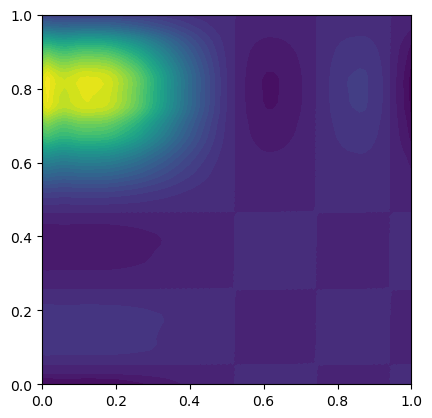

In [4]:
f_hat = solver.solve(y, r_s=1, w=w)
plot(f_hat)

[##############################] 5000/5000 (dX=2.2e-02)

Returning lowest error solution (iteration 2331)


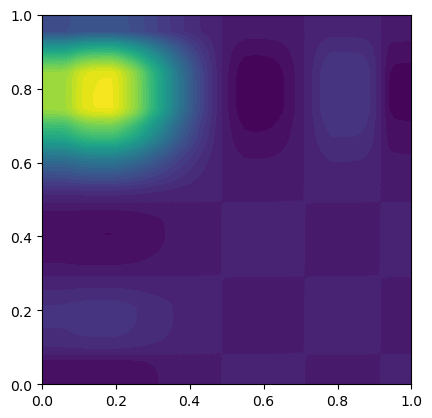

In [5]:
f_hat = solver.solve(y, r_s=1, w=w,
    beta=1e-9,
    projection=False
)
plot(f_hat)

[######################        ] 3675/5000 (dX=0.0e+00)
Converged at iteration 3675
Returning lowest error solution (iteration 3611)


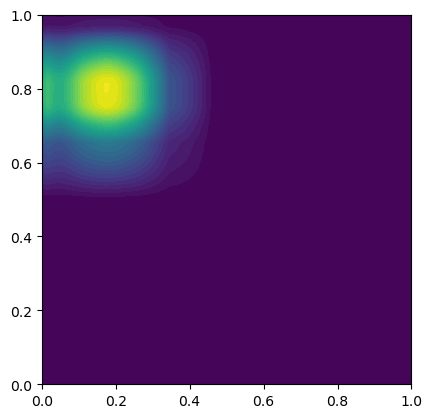

In [6]:
f_hat = solver.solve(y, r_s=1, w=w,
    projection=True
)
plot(f_hat)